In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [2]:
np.random.seed(42)
M = 1000
n_epochs = 1
maxNumIter = M * n_epochs

# Gerar dados
x1 = np.random.randn(M)
x2 = np.random.randn(M)
w = np.random.randn(M)
y_noisy = 2.5 * x1 + 1.3 * x2 + w

X = np.c_[x1, x2]
Y = y_noisy.reshape(-1, 1)

In [3]:
# Função para calcular erro
def compute_mse(X, Y, a):
    y_pred = X @ a
    mse = np.mean((Y - y_pred) ** 2)
    return mse

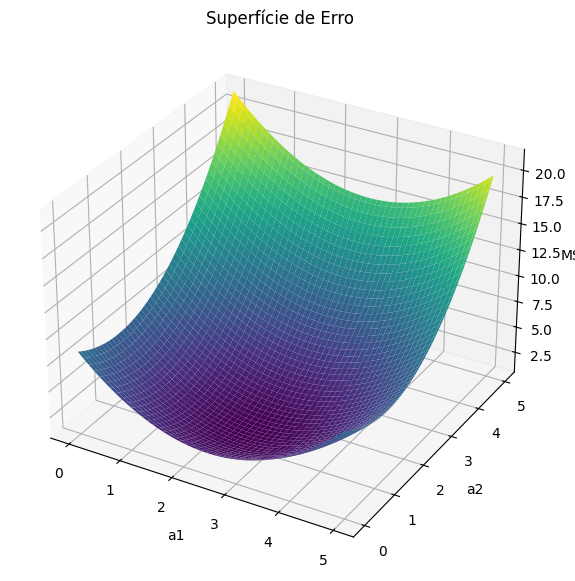

In [4]:
# (a) Plotar Superfície de Erro
a1_range = np.linspace(0, 5, 100)
a2_range = np.linspace(0, 5, 100)
A1, A2 = np.meshgrid(a1_range, a2_range)
MSE_surface = np.zeros_like(A1)

for i in range(A1.shape[0]):
    for j in range(A1.shape[1]):
        a_tmp = np.array([[A1[i, j]], [A2[i, j]]])
        MSE_surface[i, j] = compute_mse(X, Y, a_tmp)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(A1, A2, MSE_surface, cmap='viridis')
ax.set_xlabel('a1')
ax.set_ylabel('a2')
ax.set_zlabel('MSE')
ax.set_title('Superfície de Erro')
plt.show()


In [5]:
# (b) Solução Analítica
A_closed = np.linalg.inv(X.T @ X) @ X.T @ Y
print("Pesos pela equação normal:", A_closed.ravel())

Pesos pela equação normal: [2.52194704 1.29026298]


In [6]:
# (c) GDE - Gradiente Descendente Estocástico
alpha = 0.01
a_gde = np.zeros((2, 1))
errors_gde = []
update_norms_gde = []

prev_error = float('inf')

a1_updates = []
a2_updates = []

for iter in range(maxNumIter):
    idx = np.random.randint(M)
    x_i = X[idx].reshape(1, -1)
    y_i = Y[idx]

    y_pred_i = x_i @ a_gde
    error = y_pred_i - y_i
    grad = x_i.T * error

    a_gde -= alpha * grad

    if iter % 10 == 0:
        mse = compute_mse(X, Y, a_gde)
        errors_gde.append(mse)
        update_norms_gde.append(np.linalg.norm(alpha * grad))
        a1_updates.append(a_gde[0,0])
        a2_updates.append(a_gde[1,0])

        if abs(mse - prev_error) < 0.001:
            print(f"Parou por convergência em {iter} iterações")
            break
        prev_error = mse


Parou por convergência em 260 iterações


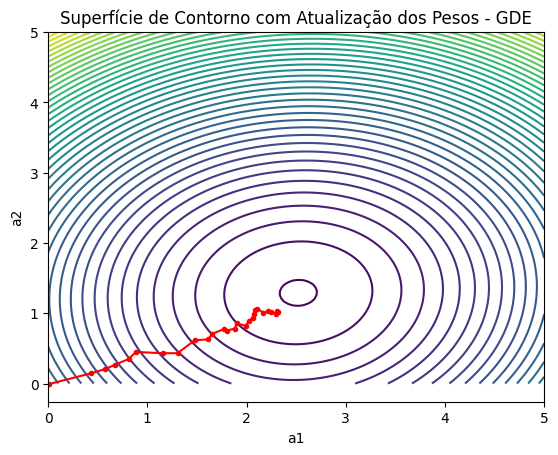

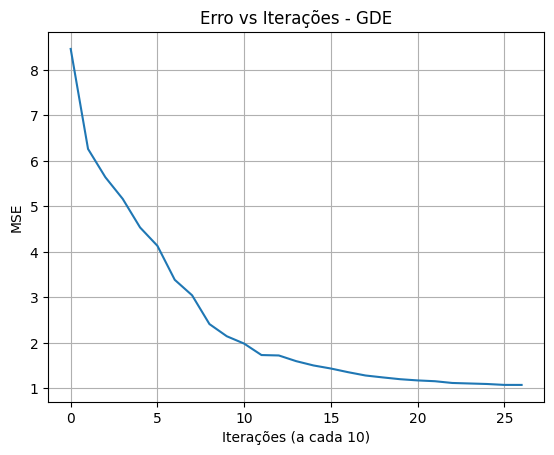

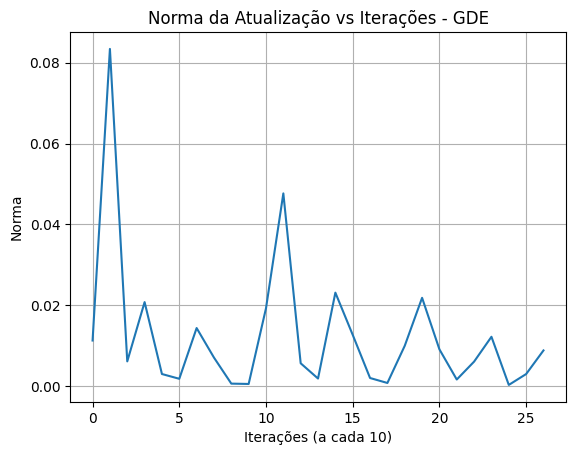

In [7]:
# (d) Plots GDE
plt.figure()
plt.contour(A1, A2, MSE_surface, levels=50)
plt.plot(a1_updates, a2_updates, 'r.-')
plt.title('Superfície de Contorno com Atualização dos Pesos - GDE')
plt.xlabel('a1')
plt.ylabel('a2')
plt.show()

plt.figure()
plt.plot(errors_gde)
plt.title('Erro vs Iterações - GDE')
plt.xlabel('Iterações (a cada 10)')
plt.ylabel('MSE')
plt.grid()
plt.show()

plt.figure()
plt.plot(update_norms_gde)
plt.title('Norma da Atualização vs Iterações - GDE')
plt.xlabel('Iterações (a cada 10)')
plt.ylabel('Norma')
plt.grid()
plt.show()


In [8]:
# (e) GDE com Decaimento Exponencial
alpha_init = 0.05
k = 0.0005
a_decay = np.zeros((2, 1))
errors_decay = []
update_norms_decay = []

prev_error = float('inf')

a1_updates_decay = []
a2_updates_decay = []

for iter in range(maxNumIter):
    idx = np.random.randint(M)
    x_i = X[idx].reshape(1, -1)
    y_i = Y[idx]

    y_pred_i = x_i @ a_decay
    error = y_pred_i - y_i
    grad = x_i.T * error

    alpha = alpha_init * np.exp(-k * iter)
    a_decay -= alpha * grad

    if iter % 10 == 0:
        mse = compute_mse(X, Y, a_decay)
        errors_decay.append(mse)
        update_norms_decay.append(np.linalg.norm(alpha * grad))
        a1_updates_decay.append(a_decay[0,0])
        a2_updates_decay.append(a_decay[1,0])

        if abs(mse - prev_error) < 0.001:
            print(f"(Decaimento) Parou por convergência em {iter} iterações")
            break
        prev_error = mse

(Decaimento) Parou por convergência em 240 iterações


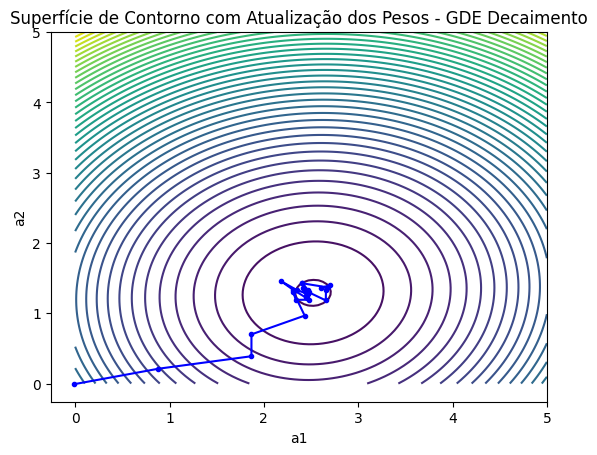

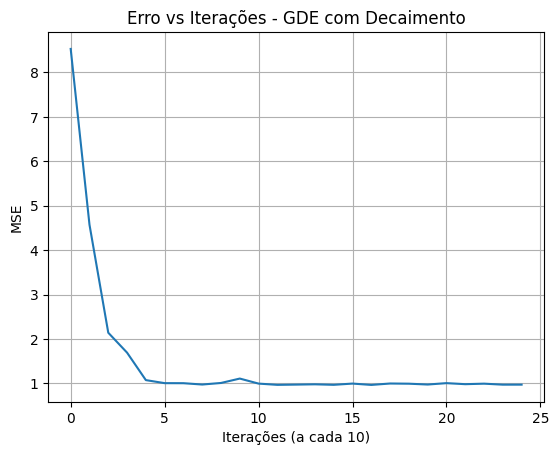

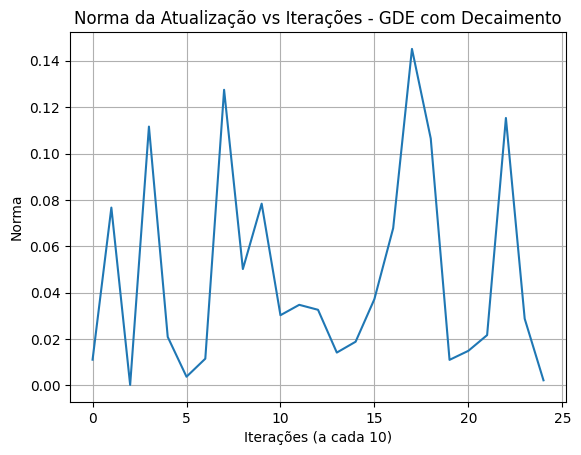

In [9]:
# (f) Plots GDE com Decaimento
plt.figure()
plt.contour(A1, A2, MSE_surface, levels=50)
plt.plot(a1_updates_decay, a2_updates_decay, 'b.-')
plt.title('Superfície de Contorno com Atualização dos Pesos - GDE Decaimento')
plt.xlabel('a1')
plt.ylabel('a2')
plt.show()

plt.figure()
plt.plot(errors_decay)
plt.title('Erro vs Iterações - GDE com Decaimento')
plt.xlabel('Iterações (a cada 10)')
plt.ylabel('MSE')
plt.grid()
plt.show()

plt.figure()
plt.plot(update_norms_decay)
plt.title('Norma da Atualização vs Iterações - GDE com Decaimento')
plt.xlabel('Iterações (a cada 10)')
plt.ylabel('Norma')
plt.grid()
plt.show()

In [10]:
# (g) Imprimir pesos finais
print("\nComparativo de pesos:")
print(f"Equação Normal: {A_closed.ravel()}")
print(f"GDE Simples: {a_gde.ravel()}")
print(f"GDE Decaimento: {a_decay.ravel()}")



Comparativo de pesos:
Equação Normal: [2.52194704 1.29026298]
GDE Simples: [2.30519607 1.02938043]
GDE Decaimento: [2.45689627 1.22260534]


# (h) Menor número de iterações?
O Gradiente Descendente Estocástico com Decaimento Exponencial precisou de menos iterações para que o critério de parada fosse atingido.
Observando o gráfico de erro vs iterações, o GDE com decaimento convergiu para valores baixos de erro muito mais rapidamente, em torno das primeiras 5-10 iterações (a cada 10 iterações plottadas), enquanto o GDE simples foi mais lento, exigindo mais iterações para estabilizar o erro.
# (i) Qual mais próximo da solução da equação normal?
Comparando os valores dos pesos finais, o GDE com decaimento exponencial obteve valores mais próximos dos pesos encontrados pela equação normal.
Isso indica que o uso do decaimento exponencial no passo de aprendizado não apenas acelerou a convergência, mas também resultou em uma solução mais precisa, reduzindo a oscilação e o erro final.